# 07 | Vision Transformer transfer learning

## Bainite–Martensite microstructure classification

This experiment evaluates an ImageNet-pretrained **ViT-B/16** under conventional stratified and physical-specimen-disjoint partitions. The objective is to assess whether patch-based self-attention representations offer different generalization behaviour from the convolutional baselines.

The preceding ResNet18 evaluation reported macro-F1 values of **0.9608** on the stratified test split and **0.6702** on the specimen-held-out split. These provide context, although performance comparisons remain specific to the partitions and training configurations used.

**Training protocol.** Images are resized to 224 × 224 pixels. A classifier-head stage is followed by partial fine-tuning of the last two transformer encoder blocks and the head. Checkpoint selection uses validation macro-F1. Both evaluation regimes use separately initialized pretrained models.

**Primary outcome:** macro-F1 on held-out physical specimens, interpreted alongside balanced accuracy, ROC-AUC, and the conventional test results.

## 1. Experimental configuration

Define split-manifest paths, output directories, model input resolution, random seed and optimization settings.

In [1]:
from pathlib import Path

PROCESSED_DIR = Path(r"../data/processed")
MODEL_DIR = Path(r"../models/07_vit")
RESULT_DIR = Path(r"../results/07_vit")

SEED = 42
IMAGE_SIZE = 224

# ViT-B/16 is heavier than ResNet18. Lower this to 8 if RAM becomes limiting.
BATCH_SIZE = 16
NUM_WORKERS = 0

HEAD_EPOCHS = 6
HEAD_LR = 1e-3

FINETUNE_EPOCHS = 24
FINETUNE_LR = 2e-5

PATIENCE = 7
MIN_DELTA = 1e-4
WEIGHT_DECAY = 1e-4

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Maximum epochs per experiment:", HEAD_EPOCHS + FINETUNE_EPOCHS)


Maximum epochs per experiment: 30


## 2. Dependencies and reproducibility

Initialize the evaluation environment, fix random seeds and select the available computation device. Exact reproducibility can depend on hardware and software versions.

In [2]:
import copy
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

from IPython.display import display

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if device.type == "cpu":
    print("CPU threads:", torch.get_num_threads())


PyTorch: 2.14.0+cpu
CUDA available: False
Device: cpu
CPU threads: 4


## 3. Evaluation manifests

Locate the stratified and specimen-disjoint manifests generated during dataset preparation. The partitions are reused without resampling to maintain consistency with earlier experiments.

In [3]:
csvs = sorted(PROCESSED_DIR.glob("*.csv"))

print("CSV files in processed directory:")
for p in csvs:
    print(" •", p.name)

def find_manifest(candidates):
    for name in candidates:
        p = PROCESSED_DIR / name
        if p.exists():
            return p
    return None

standard_path = find_manifest([
    "split_baseline_stratified.csv",
    "standard_stratified_split.csv",
    "standard_stratified.csv",
])

sample_path = find_manifest([
    "split_sample_grouped.csv",
    "sample_grouped_split.csv",
    "sample_grouped.csv",
])

# Flexible fallback based on filenames.
if standard_path is None:
    matches = [p for p in csvs if "standard" in p.name.lower() and "split" in p.name.lower()]
    if len(matches) == 1:
        standard_path = matches[0]

if sample_path is None:
    matches = [p for p in csvs if "sample" in p.name.lower() and "split" in p.name.lower()]
    if len(matches) == 1:
        sample_path = matches[0]

assert standard_path is not None, "Could not identify standard-stratified split CSV."
assert sample_path is not None, "Could not identify sample-grouped split CSV."

print("\nStandard:", standard_path)
print("Sample grouped:", sample_path)


CSV files in processed directory:
 • clean_manifest.csv
 • split_baseline_stratified.csv
 • split_holdout_magnification_100x.csv
 • split_holdout_magnification_20x.csv
 • split_holdout_magnification_50x.csv
 • split_holdout_microscope_0.csv
 • split_holdout_microscope_1.csv
 • split_holdout_microscope_2.csv
 • split_sample_grouped.csv

Standard: ..\data\processed\split_baseline_stratified.csv
Sample grouped: ..\data\processed\split_sample_grouped.csv


## 4. Partition audit

Inspect phase counts and specimen membership in each subset before fitting the model. The specimen-grouped protocol requires disjoint physical-specimen identities across training, validation and test sets.

In [4]:
experiments = {
    "standard_stratified": pd.read_csv(standard_path),
    "sample_grouped": pd.read_csv(sample_path),
}

audit_rows = []

for name, df in experiments.items():
    required = {"image_path", "Phase", "label", "split"}
    missing = required - set(df.columns)
    assert not missing, f"{name}: missing {missing}"

    used = df[df["split"].isin(["train", "val", "test"])]
    assert all(Path(p).exists() for p in used["image_path"]), f"{name}: missing image paths"

    for split in ["train", "val", "test"]:
        d = df[df["split"] == split]
        assert len(d) > 0
        assert d["Phase"].nunique() == 2
        audit_rows.append({
            "experiment": name,
            "split": split,
            "n_images": len(d),
            "bainite": int((d["Phase"] == "Bainite").sum()),
            "martensite": int((d["Phase"] == "Martensite").sum()),
            "n_samples": d["SampleIDHarm"].nunique() if "SampleIDHarm" in d else np.nan,
        })

audit = pd.DataFrame(audit_rows)
display(audit)


,experiment,split,n_images,bainite,martensite,n_samples
0,standard_stratified,train,3705,1729,1976,20
1,standard_stratified,val,794,370,424,20
2,standard_stratified,test,794,371,423,20
3,sample_grouped,train,3811,1786,2025,14
4,sample_grouped,val,722,342,380,3
5,sample_grouped,test,760,342,418,3


## 5. Input transformations

The pretrained ViT receives 224 × 224 RGB images normalized with ImageNet channel statistics. Training-only augmentation is kept moderate; validation and test transformations remain deterministic.

In [5]:
weights = ViT_B_16_Weights.DEFAULT

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


## 6. Dataset and mini-batch loading

Construct the image dataset and DataLoaders from each manifest, retaining record-level identifiers for evaluation and prediction export.

In [6]:
class MicrostructureDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as img:
            image = img.convert("RGB")

        image = self.transform(image)
        label = torch.tensor(int(row["label"]), dtype=torch.long)
        return image, label, idx


def make_loaders(df):
    parts = {
        s: df[df["split"] == s].copy()
        for s in ["train", "val", "test"]
    }

    datasets = {
        s: MicrostructureDataset(
            parts[s],
            train_transform if s == "train" else eval_transform,
        )
        for s in parts
    }

    common = dict(
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    generator = torch.Generator().manual_seed(SEED)

    loaders = {
        "train": DataLoader(
            datasets["train"],
            shuffle=True,
            generator=generator,
            **common,
        ),
        "val": DataLoader(datasets["val"], shuffle=False, **common),
        "test": DataLoader(datasets["test"], shuffle=False, **common),
    }

    return parts, datasets, loaders


## 7. ViT-B/16 adaptation strategy

The pretrained model contains 12 transformer encoder blocks. Adaptation proceeds in two stages:

- **Classifier adaptation:** freeze the transformer backbone and optimize the replacement binary-classification head.
- **Partial fine-tuning:** update the final two encoder blocks together with the classification head.

This limits the number of trainable parameters compared with full-backbone fine-tuning and reduces the computational cost of the experiment.

In [7]:
def build_model():
    model = vit_b_16(weights=weights)

    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, 2)

    return model


def freeze_backbone(model):
    for p in model.parameters():
        p.requires_grad = False

    for p in model.heads.parameters():
        p.requires_grad = True


def unfreeze_last_two_blocks(model):
    for p in model.parameters():
        p.requires_grad = False

    # ViT-B/16 has encoder_layer_0 ... encoder_layer_11.
    for block_name in ["encoder_layer_10", "encoder_layer_11"]:
        block = getattr(model.encoder.layers, block_name)
        for p in block.parameters():
            p.requires_grad = True

    # Final encoder LayerNorm can adapt as well.
    for p in model.encoder.ln.parameters():
        p.requires_grad = True

    for p in model.heads.parameters():
        p.requires_grad = True


def parameter_report(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters    : {total:,}")
    print(f"Trainable parameters: {trainable:,}")
    print(f"Trainable fraction  : {100*trainable/total:.2f}%")


## 8. Evaluation metrics

Compute classification accuracy, balanced accuracy, macro-averaged metrics and ROC-AUC from test predictions and class probabilities. Macro-F1 is the primary model-comparison measure.

In [8]:
def compute_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }


@torch.inference_mode()
def evaluate(model, loader, criterion):
    model.eval()

    loss_sum = 0.0
    y_true, y_pred, y_prob, indices = [], [], [], []

    for x, target, idx in loader:
        x = x.to(device)
        target = target.to(device)

        logits = model(x)
        loss = criterion(logits, target)

        prob = torch.softmax(logits, dim=1)[:, 1]
        pred = logits.argmax(dim=1)

        loss_sum += loss.item() * x.size(0)
        y_true.extend(target.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
        y_prob.extend(prob.cpu().numpy())
        indices.extend(idx.numpy())

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["loss"] = loss_sum / len(loader.dataset)

    return (
        metrics,
        np.asarray(y_true),
        np.asarray(y_pred),
        np.asarray(y_prob),
        np.asarray(indices),
    )


## 9. Stage-wise training

Monitor training and validation performance during optimization. The best checkpoint is selected by validation macro-F1 rather than by test-set performance.

In [9]:
def train_stage(
    model,
    datasets,
    loaders,
    stage_name,
    max_epochs,
    lr,
    best_f1=-np.inf,
    best_state=None,
    epoch_offset=0,
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
    )

    history = []
    stale = 0

    for local_epoch in range(1, max_epochs + 1):
        epoch = epoch_offset + local_epoch
        model.train()

        loss_sum = 0.0
        y_true, y_pred, y_prob = [], [], []

        for x, target, _ in loaders["train"]:
            x = x.to(device)
            target = target.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(x)
            loss = criterion(logits, target)
            loss.backward()
            optimizer.step()

            prob = torch.softmax(logits, dim=1)[:, 1]
            pred = logits.argmax(dim=1)

            loss_sum += loss.item() * x.size(0)
            y_true.extend(target.detach().cpu().numpy())
            y_pred.extend(pred.detach().cpu().numpy())
            y_prob.extend(prob.detach().cpu().numpy())

        train_m = compute_metrics(y_true, y_pred, y_prob)
        train_m["loss"] = loss_sum / len(datasets["train"])

        val_m, *_ = evaluate(model, loaders["val"], criterion)

        scheduler.step(val_m["f1_macro"])
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "stage": stage_name,
            "lr": current_lr,
            **{f"train_{k}": v for k, v in train_m.items()},
            **{f"val_{k}": v for k, v in val_m.items()},
        })

        print(
            f"Epoch {epoch:02d} | {stage_name:10s} | "
            f"train F1 {train_m['f1_macro']:.4f} | "
            f"val F1 {val_m['f1_macro']:.4f} | "
            f"val AUC {val_m['roc_auc']:.4f} | "
            f"lr {current_lr:.1e}"
        )

        if val_m["f1_macro"] > best_f1 + MIN_DELTA:
            best_f1 = val_m["f1_macro"]
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1

        if stale >= PATIENCE:
            print(f"Early stopping {stage_name}.")
            break

    return model, pd.DataFrame(history), best_f1, best_state


## 10. Experiment execution

Each partition is evaluated using a separately initialized ImageNet-pretrained ViT-B/16. The highest-validation-F1 checkpoint across both adaptation stages is restored for test evaluation and artifact export.

In [10]:
def run_experiment(name, df):
    print("\n" + "="*90)
    print("ViT-B/16:", name)
    print("="*90)

    set_seed(SEED)

    parts, datasets, loaders = make_loaders(df)

    model = build_model().to(device)
    start = time.time()

    print("\nSTAGE 1 — CLASSIFIER HEAD")
    freeze_backbone(model)
    parameter_report(model)

    model, h1, best_f1, best_state = train_stage(
        model,
        datasets,
        loaders,
        "head",
        HEAD_EPOCHS,
        HEAD_LR,
    )

    model.load_state_dict(best_state)

    print("\nSTAGE 2 — LAST TWO TRANSFORMER BLOCKS")
    unfreeze_last_two_blocks(model)
    parameter_report(model)

    model, h2, best_f1, best_state = train_stage(
        model,
        datasets,
        loaders,
        "fine_tune",
        FINETUNE_EPOCHS,
        FINETUNE_LR,
        best_f1,
        best_state,
        len(h1),
    )

    model.load_state_dict(best_state)

    history = pd.concat([h1, h2], ignore_index=True)

    criterion = nn.CrossEntropyLoss()
    test_m, y, pred, prob, indices = evaluate(
        model,
        loaders["test"],
        criterion,
    )

    elapsed = (time.time() - start) / 60

    checkpoint = MODEL_DIR / f"{name}_vit_b16_best.pt"

    torch.save({
        "model_state_dict": best_state,
        "architecture": "vit_b_16",
        "image_size": IMAGE_SIZE,
        "label_map": {"Bainite": 0, "Martensite": 1},
        "best_val_macro_f1": float(best_f1),
        "seed": SEED,
        "head_epochs": HEAD_EPOCHS,
        "finetune_epochs": FINETUNE_EPOCHS,
    }, checkpoint)

    history.to_csv(
        RESULT_DIR / f"{name}_history.csv",
        index=False,
    )

    test_df = parts["test"].reset_index(drop=True)
    pred_df = test_df.iloc[indices].reset_index(drop=True).copy()

    pred_df["true_label"] = y
    pred_df["predicted_label"] = pred
    pred_df["p_martensite"] = prob
    pred_df["predicted_phase"] = pd.Series(pred).map({
        0: "Bainite",
        1: "Martensite",
    })

    pred_df.to_csv(
        RESULT_DIR / f"{name}_test_predictions.csv",
        index=False,
    )

    print("\nTEST RESULTS")
    for k, v in test_m.items():
        print(f"{k:20s}: {v:.4f}")

    print(f"Training time       : {elapsed:.1f} min")
    print("Checkpoint          :", checkpoint)

    return {
        "name": name,
        "metrics": test_m,
        "history": history,
        "y": y,
        "pred": pred,
        "prob": prob,
        "minutes": elapsed,
        "checkpoint": checkpoint,
    }


## 11. ViT experiments

Train and evaluate the model separately on the conventional stratified partition and the physical-specimen-disjoint partition. Each experiment records its own model checkpoint, metrics and prediction-level outputs.

In [11]:
results = {}

for name, df in experiments.items():
    results[name] = run_experiment(name, df)

print("\n✓ Both ViT experiments completed.")



ViT-B/16: standard_stratified
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|███████████████████████████████████████████████████████████████████████████████| 330M/330M [00:06<00:00, 51.6MB/s]



STAGE 1 — CLASSIFIER HEAD
Total parameters    : 85,800,194
Trainable parameters: 1,538
Trainable fraction  : 0.00%
Epoch 01 | head       | train F1 0.8020 | val F1 0.8323 | val AUC 0.9088 | lr 1.0e-03
Epoch 02 | head       | train F1 0.8471 | val F1 0.8414 | val AUC 0.9229 | lr 1.0e-03
Epoch 03 | head       | train F1 0.8643 | val F1 0.8550 | val AUC 0.9302 | lr 1.0e-03
Epoch 04 | head       | train F1 0.8712 | val F1 0.8625 | val AUC 0.9374 | lr 1.0e-03
Epoch 05 | head       | train F1 0.8684 | val F1 0.8728 | val AUC 0.9401 | lr 1.0e-03
Epoch 06 | head       | train F1 0.8762 | val F1 0.8784 | val AUC 0.9461 | lr 1.0e-03

STAGE 2 — LAST TWO TRANSFORMER BLOCKS
Total parameters    : 85,800,194
Trainable parameters: 14,178,818
Trainable fraction  : 16.53%
Epoch 07 | fine_tune  | train F1 0.8756 | val F1 0.8601 | val AUC 0.9578 | lr 2.0e-05
Epoch 08 | fine_tune  | train F1 0.8906 | val F1 0.8681 | val AUC 0.9648 | lr 2.0e-05
Epoch 09 | fine_tune  | train F1 0.9094 | val F1 0.9104 | val 

## 12. Test-set results

Consolidate the evaluation metrics from both experiments. The distinction between image-level and specimen-disjoint test populations is retained in all comparisons.

In [12]:
rows = []

for name, r in results.items():
    m = r["metrics"]

    rows.append({
        "Evaluation": name,
        "Accuracy": m["accuracy"],
        "Balanced Accuracy": m["balanced_accuracy"],
        "Macro Precision": m["precision_macro"],
        "Macro Recall": m["recall_macro"],
        "Macro F1": m["f1_macro"],
        "ROC-AUC": m["roc_auc"],
        "Training time (min)": r["minutes"],
    })

vit_summary = pd.DataFrame(rows)

display(
    vit_summary.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Training time (min)": "{:.1f}",
    })
)

vit_summary.to_csv(
    RESULT_DIR / "vit_summary.csv",
    index=False,
)


,Evaluation,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,Training time (min)
0,standard_stratified,0.9408,0.9393,0.9421,0.9393,0.9404,0.9877,628.3
1,sample_grouped,0.7526,0.7493,0.7502,0.7493,0.7497,0.8190,544.2


## 13. Comparison with convolutional baselines

Compare ViT-B/16 against the custom CNN and ResNet18 results from the earlier experiments. As all values are based on the respective evaluation protocols, the comparison describes observed performance rather than demonstrating an architecture-specific causal effect.

In [13]:
baseline = pd.DataFrame([
    ["Custom CNN", "standard_stratified", 0.7809, 0.7789, 0.8582],
    ["ResNet18", "standard_stratified", 0.9610, 0.9608, 0.9934],
    ["Custom CNN", "sample_grouped", 0.6487, 0.6405, 0.7094],
    ["ResNet18", "sample_grouped", 0.6711, 0.6702, 0.7747],
], columns=["Model", "Evaluation", "Accuracy", "Macro F1", "ROC-AUC"])

vit_compare = vit_summary[
    ["Evaluation", "Accuracy", "Macro F1", "ROC-AUC"]
].copy()

vit_compare.insert(0, "Model", "ViT-B/16")

comparison = pd.concat(
    [baseline, vit_compare],
    ignore_index=True,
)

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Macro F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
    })
)

comparison.to_csv(
    RESULT_DIR / "cnn_resnet_vit_comparison.csv",
    index=False,
)


,Model,Evaluation,Accuracy,Macro F1,ROC-AUC
0,Custom CNN,standard_stratified,0.7809,0.7789,0.8582
1,ResNet18,standard_stratified,0.9610,0.9608,0.9934
2,Custom CNN,sample_grouped,0.6487,0.6405,0.7094
3,ResNet18,sample_grouped,0.6711,0.6702,0.7747
4,ViT-B/16,standard_stratified,0.9408,0.9404,0.9877
5,ViT-B/16,sample_grouped,0.7526,0.7497,0.8190


## 14. Conventional-to-grouped performance gap

Calculate the difference in test performance between the stratified and specimen-disjoint protocols for each architecture. Because the test populations differ, this gap quantifies evaluation-protocol sensitivity rather than isolating any single physical mechanism.

In [14]:
gap_rows = []

for model_name in comparison["Model"].unique():
    d = comparison[comparison["Model"] == model_name]

    if set(d["Evaluation"]) >= {"standard_stratified", "sample_grouped"}:
        standard_f1 = float(
            d.loc[d["Evaluation"] == "standard_stratified", "Macro F1"].iloc[0]
        )
        unseen_f1 = float(
            d.loc[d["Evaluation"] == "sample_grouped", "Macro F1"].iloc[0]
        )

        gap_rows.append({
            "Model": model_name,
            "Standard Macro-F1": standard_f1,
            "Unseen-sample Macro-F1": unseen_f1,
            "Generalization gap": standard_f1 - unseen_f1,
        })

gap_df = pd.DataFrame(gap_rows)

display(
    gap_df.style.format({
        "Standard Macro-F1": "{:.4f}",
        "Unseen-sample Macro-F1": "{:.4f}",
        "Generalization gap": "{:.4f}",
    })
)


,Model,Standard Macro-F1,Unseen-sample Macro-F1,Generalization gap
0,Custom CNN,0.7789,0.6405,0.1384
1,ResNet18,0.9608,0.6702,0.2906
2,ViT-B/16,0.9404,0.7497,0.1907


## 15. Macro-F1 comparison

Visualize the architecture results under both evaluation protocols, with particular attention to how model rankings change when physical specimens are held out.

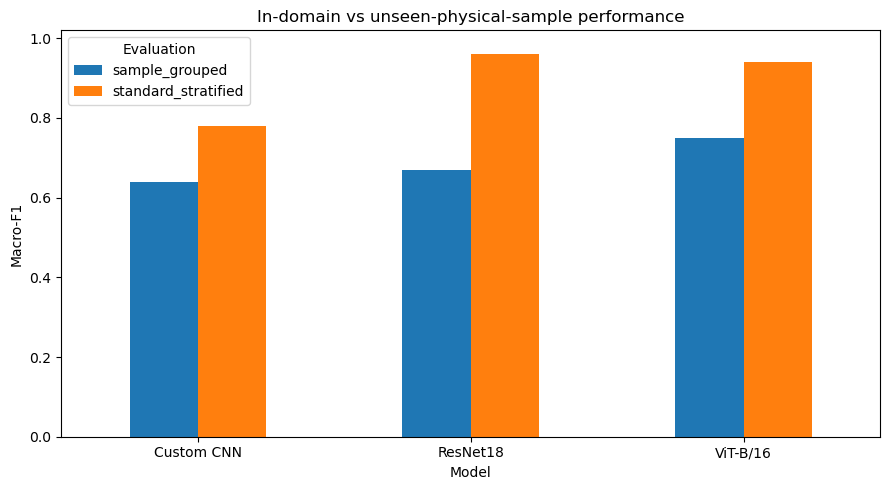

In [15]:
plot_df = comparison.pivot(
    index="Model",
    columns="Evaluation",
    values="Macro F1",
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_ylim(0, 1.02)
ax.set_ylabel("Macro-F1")
ax.set_xlabel("Model")
ax.set_title("In-domain vs unseen-physical-sample performance")
ax.legend(title="Evaluation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 16. Confusion matrices

Inspect class-specific errors within each test partition. Asymmetric Bainite/Martensite misclassification may reveal effects that are not evident from aggregate macro-F1 alone.

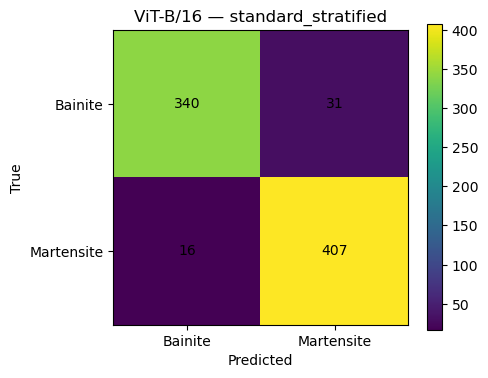

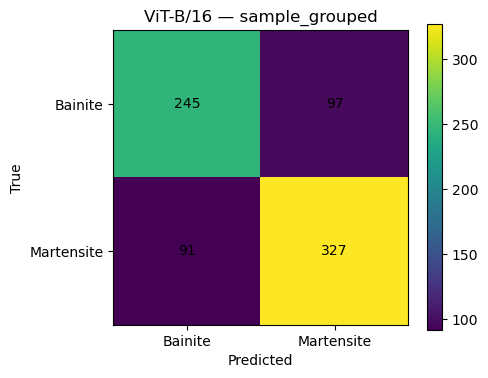

In [16]:
for name, r in results.items():
    cm = confusion_matrix(r["y"], r["pred"])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)

    ax.set_xticks([0, 1], ["Bainite", "Martensite"])
    ax.set_yticks([0, 1], ["Bainite", "Martensite"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"ViT-B/16 — {name}")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()


## 17. Training dynamics

Plot training and validation macro-F1 histories to assess convergence, checkpoint selection and signs of overfitting within each evaluation protocol.

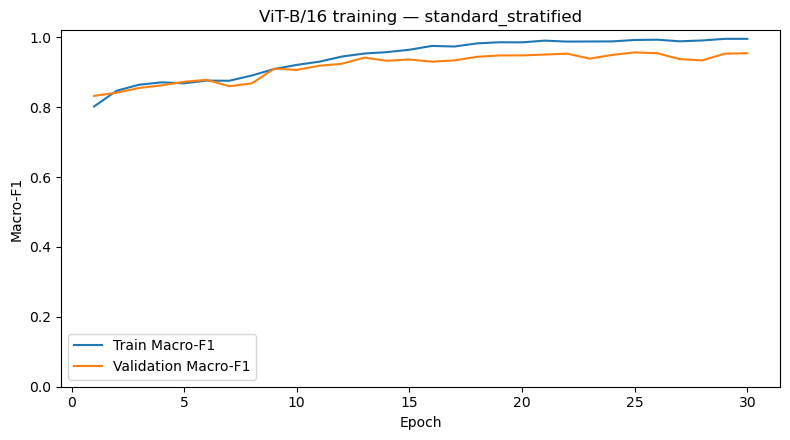

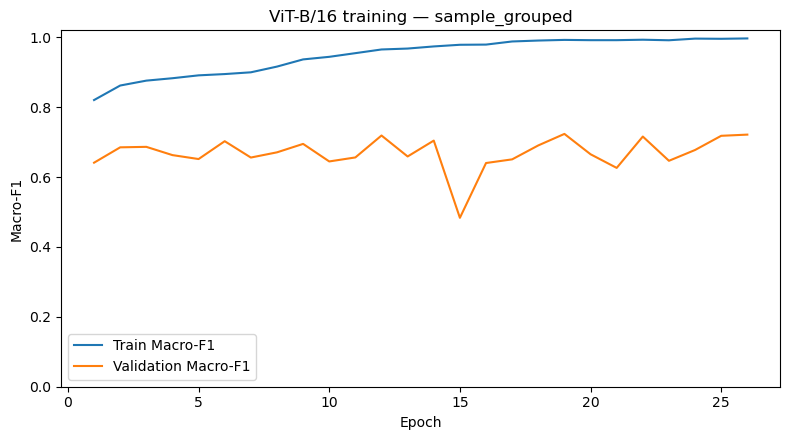

In [17]:
for name, r in results.items():
    h = r["history"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(h["epoch"], h["train_f1_macro"], label="Train Macro-F1")
    ax.plot(h["epoch"], h["val_f1_macro"], label="Validation Macro-F1")
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro-F1")
    ax.set_title(f"ViT-B/16 training — {name}")
    ax.legend()
    fig.tight_layout()
    plt.show()


## 18. Experimental summary

Report the final accuracy, balanced accuracy, macro-F1 and ROC-AUC for both ViT-B/16 experiments. Interpretation prioritizes generalization to previously unseen physical specimens rather than maximizing the conventional stratified score.

In [18]:
print("="*88)
print("VISION TRANSFORMER SUMMARY")
print("="*88)

for _, row in vit_summary.iterrows():
    print(f"\n{row['Evaluation']}")
    print(f"  Accuracy          : {row['Accuracy']:.4f}")
    print(f"  Balanced Accuracy : {row['Balanced Accuracy']:.4f}")
    print(f"  Macro-F1          : {row['Macro F1']:.4f}")
    print(f"  ROC-AUC           : {row['ROC-AUC']:.4f}")
    print(f"  Training time     : {row['Training time (min)']:.1f} min")

vit_std = float(
    vit_summary.loc[
        vit_summary["Evaluation"] == "standard_stratified",
        "Macro F1",
    ].iloc[0]
)

vit_unseen = float(
    vit_summary.loc[
        vit_summary["Evaluation"] == "sample_grouped",
        "Macro F1",
    ].iloc[0]
)

print("\nRESNET18 REFERENCE")
print("  Standard Macro-F1      : 0.9608")
print("  Unseen-sample Macro-F1 : 0.6702")

print("\nViT GENERALIZATION")
print(f"  Standard → unseen gap  : {vit_std - vit_unseen:.4f}")
print(f"  Δ vs ResNet standard   : {vit_std - 0.9608:+.4f}")
print(f"  Δ vs ResNet unseen     : {vit_unseen - 0.6702:+.4f}")

print("\nSaved:")
print(" •", RESULT_DIR / "vit_summary.csv")
print(" •", RESULT_DIR / "cnn_resnet_vit_comparison.csv")

print("\nNEXT: 08_swin_transfer_learning.ipynb")
print("="*88)


VISION TRANSFORMER SUMMARY

standard_stratified
  Accuracy          : 0.9408
  Balanced Accuracy : 0.9393
  Macro-F1          : 0.9404
  ROC-AUC           : 0.9877
  Training time     : 628.3 min

sample_grouped
  Accuracy          : 0.7526
  Balanced Accuracy : 0.7493
  Macro-F1          : 0.7497
  ROC-AUC           : 0.8190
  Training time     : 544.2 min

RESNET18 REFERENCE
  Standard Macro-F1      : 0.9608
  Unseen-sample Macro-F1 : 0.6702

ViT GENERALIZATION
  Standard → unseen gap  : 0.1907
  Δ vs ResNet standard   : -0.0204
  Δ vs ResNet unseen     : +0.0795

Saved:
 • ..\results\07_vit\vit_summary.csv
 • ..\results\07_vit\cnn_resnet_vit_comparison.csv

NEXT: 08_swin_transfer_learning.ipynb


## Interpretation and limitations

The experiment tests whether an ImageNet-pretrained Vision Transformer changes classification performance under two distinct evaluation protocols. Any improvement over convolutional baselines must be interpreted alongside training differences, the limited number of evaluated partitions and the specimen composition of the held-out set.

The stratified split may include correlated images from the same physical specimens in training and testing; its performance should not be characterized as unseen-specimen generalization. Conversely, a single specimen-grouped split does not establish stable performance across all possible held-out specimens. Repeated grouped evaluation is needed to assess the robustness of apparent architecture rankings.